In [371]:
#Imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings                                              
from sklearn.exceptions import DataConversionWarning          
warnings.filterwarnings(action='ignore', category=DataConversionWarning)

In [372]:
#Reading Data
data= pd.read_csv('/Users/dimitriosgretsistas/Desktop/AI-ENG-BOOTCAMP/ironhack-w2-project/training (2).csv')
data.shape
data.columns
data.head()

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882


In [373]:
#Cleaning Data
#Dropping irrelevant columns
data.drop(columns=['Unnamed: 0'], inplace=True)
data.head()
data.shape
data.dtypes
print(data.isna().sum())

store_ID               0
day_of_week            0
date                   0
nb_customers_on_day    0
open                   0
promotion              0
state_holiday          0
school_holiday         0
sales                  0
dtype: int64


In [374]:
def one_hot_encode_state_holidays(df):
    return pd.get_dummies(df, columns=['state_holiday'], dtype=int)

df_1 = one_hot_encode_state_holidays(data)


def one_hot_encode_date(df):
    df['date'] = pd.to_datetime(df['date'], dayfirst=True)
    df['year'] = df['date'].dt.year.astype(int)
    df['month'] = df['date'].dt.month.astype(int)
    df['day'] = df['date'].dt.day.astype(int)
    df['day_of_week'] = df['date'].dt.dayofweek.astype(int)
    df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
    df = df.drop(columns=['date'])
    return df

df_2=one_hot_encode_date(df_1)

df_2.head()

cleaned_df=df_2
cleaned_df

/var/folders/bx/plft7xbx3rgg3bcc25nmq0wm0000gn/T/ipykernel_52480/3713905519.py:8: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'], dayfirst=True)


,store_ID,day_of_week,nb_customers_on_day,open,promotion,school_holiday,sales,state_holiday_0,state_holiday_a,state_holiday_b,state_holiday_c,year,month,day,week_of_year
0,366,3,517,1,0,0,4422,1,0,0,0,2013,4,18,16
1,394,5,694,1,0,0,8297,1,0,0,0,2015,4,11,15
2,807,3,970,1,1,0,9729,1,0,0,0,2013,8,29,35
3,802,1,473,1,1,0,6513,1,0,0,0,2013,5,28,22
4,726,3,1068,1,1,0,10882,1,0,0,0,2013,10,10,41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
640835,409,5,483,1,0,0,4553,1,0,0,0,2013,10,26,43
640836,97,0,987,1,1,0,12307,1,0,0,0,2014,4,14,16
640837,987,0,925,1,0,0,6800,1,0,0,0,2014,7,7,28
640838,1084,3,725,1,0,0,5344,1,0,0,0,2014,6,12,24


In [375]:
#Filtering Open & ID
df_days_opened = cleaned_df[cleaned_df['open'] == 1].copy()
df_days_opened.drop('open', axis=1, inplace=True)
df_days_opened

#Filtering the store_ID & drop
df_without_ID = cleaned_df.drop('store_ID', axis=1)
df_without_ID

df_days_opened_without_ID = df_days_opened.drop('store_ID', axis=1)
df_days_opened_without_ID

,day_of_week,nb_customers_on_day,promotion,school_holiday,sales,state_holiday_0,state_holiday_a,state_holiday_b,state_holiday_c,year,month,day,week_of_year
0,3,517,0,0,4422,1,0,0,0,2013,4,18,16
1,5,694,0,0,8297,1,0,0,0,2015,4,11,15
2,3,970,1,0,9729,1,0,0,0,2013,8,29,35
3,1,473,1,0,6513,1,0,0,0,2013,5,28,22
4,3,1068,1,0,10882,1,0,0,0,2013,10,10,41
...,...,...,...,...,...,...,...,...,...,...,...,...,...
640833,5,701,0,0,8219,1,0,0,0,2015,1,17,3
640835,5,483,0,0,4553,1,0,0,0,2013,10,26,43
640836,0,987,1,0,12307,1,0,0,0,2014,4,14,16
640837,0,925,0,0,6800,1,0,0,0,2014,7,7,28


In [376]:
#cleaned_df is the cleaned version
#df_days_opened is filtered without the days the shops were closed (0)
#df_without_ID is fitered without the stores IDs
#df_days_opened_without_ID is both last combined 

Index(['day_of_week', 'nb_customers_on_day', 'promotion', 'school_holiday',
       'sales', 'state_holiday_0', 'state_holiday_a', 'state_holiday_b',
       'state_holiday_c', 'year', 'month', 'day'],
      dtype='object')


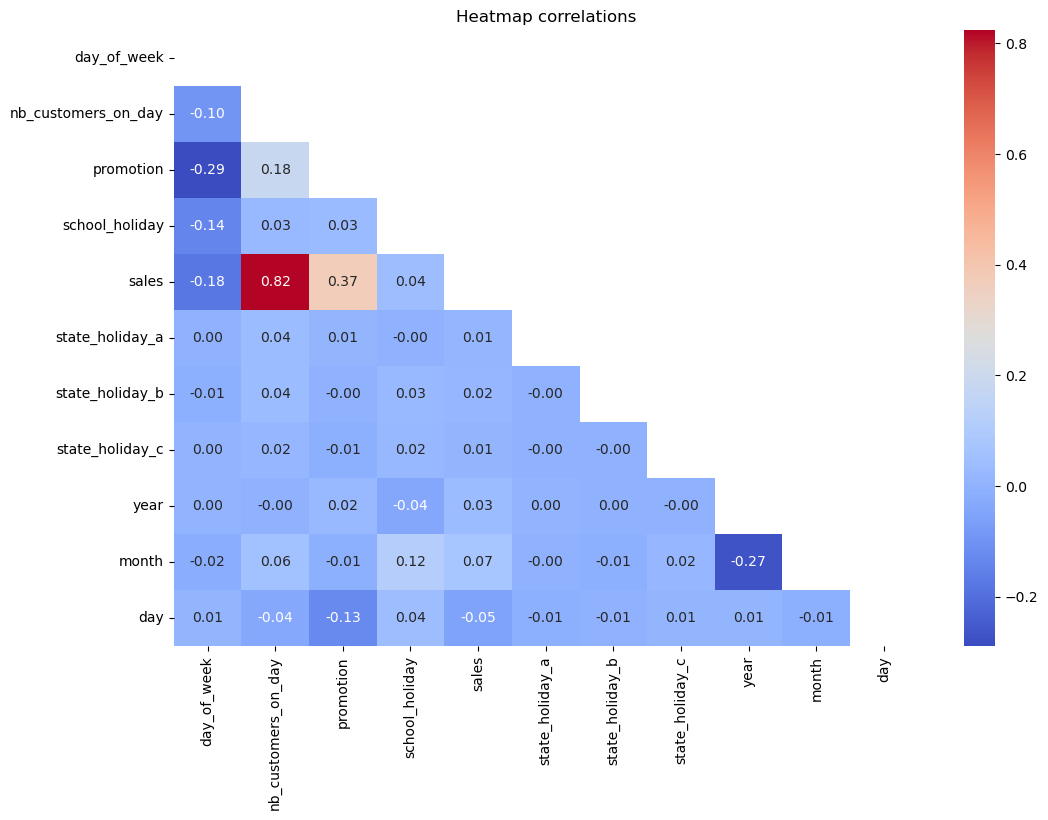

In [377]:
#Correlation
def display_heatmap(df):
    corr = df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize = (12,8))
    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="coolwarm"
    )

    plt.title("Heatmap correlations")
    plt.show()


#Drop Week_of_year 
df_days_opened_without_ID.drop( 'week_of_year', axis=1, inplace=True)
#display_heatmap(df_days_opened_without_ID)


#Observations
print(df_days_opened_without_ID.columns)
df_days_opened_without_ID.drop('state_holiday_0', axis=1, inplace=True)
display_heatmap(df_days_opened_without_ID)

In [378]:
#Train Model

#Def9ne X and y
X = df_days_opened_without_ID.drop("sales", axis=1)
y = df_days_opened_without_ID["sales"]

#Train, Test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test  = train_test_split(X,y, test_size=0.2, random_state=0)

#Linear Regression Train
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

#preditcions
y_pred = model.predict(X_test)

#Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MEA:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))
y.mean()

MEA: 1148.3674008363184
MSE: 2555627.6988038453
R2: 0.7318201051657711


np.float64(6959.251678520946)

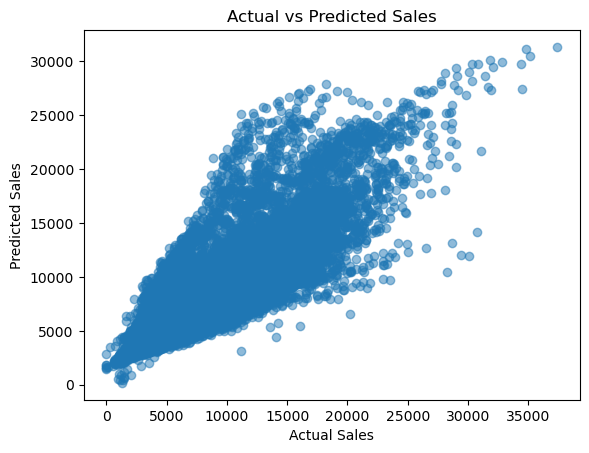

In [379]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

In [380]:
#real data 
# Load
new_data = pd.read_csv('/Users/dimitriosgretsistas/Desktop/AI-ENG-BOOTCAMP/ironhack-w2-project/REAL_DATA.csv')

# clean
new_data.drop(columns=['index'], inplace=True, errors='ignore')

# pre-processing
new_df_1 = one_hot_encode_state_holidays(new_data)
new_df_2 = one_hot_encode_date(new_df_1)

# filter open and drop
new_days_opened = new_df_2[new_df_2['open'] == 1].copy()
new_days_opened.drop('open', axis=1, inplace=True)

# drop the id
new_days_opened_without_ID = new_days_opened.drop('store_ID', axis=1)

# drop irrelevant columns
new_days_opened_without_ID.drop('week_of_year', axis=1, inplace=True, errors='ignore')
new_days_opened_without_ID.drop('state_holiday_0', axis=1, inplace=True, errors='ignore')

# features
new_X = new_days_opened_without_ID.reindex(columns=X.columns, fill_value=0)

# Predict
predicted_sales = model.predict(new_X)

# save the opredicted sales
new_days_opened_without_ID['predicted_sales'] = predicted_sales

new_days_opened_without_ID.head(20)

,day_of_week,nb_customers_on_day,promotion,school_holiday,state_holiday_a,state_holiday_b,state_holiday_c,year,month,day,predicted_sales
2,2,657,1,0,0,0,0,2014,3,19,7009.884209
3,1,862,0,0,0,0,0,2013,1,29,6744.597059
4,2,591,1,0,0,0,0,2014,3,19,6611.016456
5,3,569,0,0,0,0,0,2014,6,26,5198.608455
6,0,321,1,0,0,0,0,2015,2,16,5250.246459
7,5,1367,0,0,0,0,0,2014,11,22,10073.064871
9,1,546,1,0,0,0,0,2015,1,13,6496.011374
10,3,968,0,1,0,0,0,2015,7,23,7851.701065
11,3,472,0,0,0,0,0,2013,9,19,4551.772369
13,0,965,0,0,0,0,0,2013,12,9,7852.229990
